# Introduction


From [the previous test and analysis](https://github.com/rxsalad/amd-recipe-development/blob/main/Numa/analysis_20260227.ipynb), we identified 5 types of traffic generated by a vLLM instance:

- **Traffic 1–3:** Easily optimized by pinning vLLM processes to a single NUMA node.

- **Traffic 5:** Not a concern due to XGMI full-mesh connectivity across 8 GPUs.

- **Traffic 4:** Varies with context length. <span style="color:red">**Short contexts with low PCIe traffic are minimally affected by GPU placement, whereas longer contexts with high concurrency can generate substantial PCIe traffic and experience significant performance degradation due to NUMA misalignment.**</span>


|   | Traffic                    | From → To              | Purpose                                                                           | Nature                                                       |
| - | -------------------------- | ---------------------- | --------------------------------------------------------------------------------- | ------------------------------------------------------------ |
| 1 | User inference             | API Server → End Users | Receive inference requests and return generated tokens                               | Low latency, small-to-medium payloads                        |
| 2 | Task dispatch              | EngineCore → Worker_TP | Assign token-generation tasks and batch instructions                              | Small-to-medium payloads, latency-sensitive                 |
| 3 | Inter-worker communication | Worker_TP ↔ Worker_TP  | Exchange intermediate activations and synchronize tensor-parallel state           | Medium-to-large payloads, latency-sensitive |
| 4 | GPU compute                | Worker_TP → GPU        | Offload heavy tensor computations for each token to GPUs, including GEMM and attention operations                        | High-bandwidth, PCIe-based traffic that is compute- and memory-bound, increasing with context length and concurrency            |
| 5 | GPU synchronization        | GPU ↔ GPU              | Synchronize model shards and exchange intermediate tensors for tensor parallelism | NVLink/xGMI, high bandwidth, latency-sensitive |



# vLLM running an 8-GPU Model

For vLLM running an 8-GPU model, such as DeepSeek V3/R1, we can assign all CPU cores from 2 NUMA nodes along with the 8 GPUs to the pod. **However, in this case, vLLM does not enforce NUMA alignment.**

### Traffic model of vLLM DeepSeek

During the generation of each token in a vLLM instance, five traffic types occur in a tightly coordinated execution loop:

- Once a token is produced, it is streamed back to the end user (**Type 1**).

- The token is appended to the sequence state (e.g., KV cache metadata and scheduler state), and the EngineCore dispatches the next-step execution request to all Worker_TP processes participating in tensor parallelism (**Type 2**).

- Each Worker_TP process then launches the required GPU kernels and transfers per-token activation and control data to its assigned GPU over PCIe (**Type 4**), where the core tensor operations—such as attention and GEMM—are executed.

- During this process, workers perform lightweight CPU-level coordination, including synchronization barriers and MoE routing or other control-plane communication (**Type 3**).

- Meanwhile, consolidation of per-layer tensor-parallel outputs—through operations such as all-reduce or all-gather—occurs directly across GPUs via high-bandwidth collective communication (**Type 5**), producing the correctly synchronized activations required for the subsequent layer.

Together, these five traffic types form the per-token execution cycle, spanning user-facing communication, CPU scheduling and coordination, PCIe-based CPU–GPU interaction, and GPU–GPU tensor-parallel synchronization.

![NUMA1](images/ds-traffic.png)

### NUMA migrations

While the vLLM DeepSeek instance was serving requests, a 10-minute observation with 1-second sampling showed that processes were continuously migrating across CPU cores and NUMA nodes (the 8 vLLM::Worker_TP processes corresponding to 8 GPUs).

![DS-NUMA1](images/ds-numa-1.png)

### Optimization for all traffic types 1/2/3, plus 50% of traffic type 4

<span style="color:red">**Since the optimization goals of traffic types 1, 2, 3, and 4 conflict on a two-NUMA-node system**</span>, it is difficult to determine whether this efficiency of the default behavior is good or poor. During process migrations across NUMA nodes, sometimes traffic types 1–3 are better optimized, while other times traffic type 4 is favored.

If only optimize traffic type 4, four workers for GPUs 0-3 could be assigned to NUMA node 0 and the remaining four for GPUs 4-7 to NUMA node 1; **however, this forces ~50% of traffic types 1–3 to span both NUMA nodes.** Additionally, vLLM does not currently support this configuration.

Conversely, to optimize traffic types 1–3, all vLLM processes can be pinned to NUMA 0 while using GPUs 0-7 from both NUMA nodes, we can ensure that all process migrations are confined within NUMA 0:

![DS-NUMA2](images/ds-numa-2.png)

However for traffic type 4, half of the Worker_TP's CPU -> GPU communication consistently achieve optimal performance, while the other half remain in the worst-case scenario:

![traffic](images/ds-numa.png)

### Test results and analysis

Based on the tested cases (input length 1024, output length 1024, and 1–40 prompts), three runs were conducted for each of the two configurations on the same MI350x8 node, and the top two results were compared:

- Solution 1: Default vLLM DeepSeek configuration using 8 GPUs without NUMA alignment ([the K8S manifest](https://github.com/rxsalad/amd-recipe-development/blob/main/DeepSeek-R1-MXFP4/20260301/350-vllm-dev.yaml))
- Solution 2: All vLLM processes pinned to NUMA node 0 while utilizing 8 GPUs ([the K8S manifest](https://github.com/rxsalad/amd-recipe-development/blob/main/DeepSeek-R1-MXFP4/20260301/numa0-350-vllm-dev.yaml))

**While Solution 2 shows a slight performance improvement, the difference is negligible.**

![traffic](images/ds-ttft.png)

![traffic](images/ds-itl.png)

![traffic](images/ds-tok-s.png)


GPU metrics revealed a substantial increase in PCIe traffic as concurrency increased. This helps explain why Solution 2 did not yield significant performance gains: **traffic type 4 for GPUs 4–7—consistently experiencing the worst-case scenario—gradually became a performance bottleneck.**

We also observed heavy GPU-to-GPU traffic over XGMI, driven primarily by tensor-parallel collectives such as all-reduce and all-gather, as well as MoE expert routing in layers where tokens are distributed across all 8 GPUs.

![traffic](images/traffic-4-5.png)

In [1]:
import json
import pandas as pd
import ast
import matplotlib.pyplot as plt
import numpy
%matplotlib inline  

In [12]:
df = pd.read_csv("./deepseek_r1_mxfp4_vllm_20260301.csv")

In [13]:
#df.info()
#df.head()

In [14]:
df['base_url'].unique()

array(['http://mi350-vllm-dev.default.svc.cluster.local:80',
       'http://mi350-vllm-latest.default.svc.cluster.local:80',
       'http://mi350-vllm.default.svc.cluster.local:80'], dtype=object)

In [15]:
df['others'].unique()

array(['doks-1.34.1-rocm-7.0.2-mi350x8-vllm-dev-dsfp4_1120',
       'doks-1.34.1-rocm-7.0.2-mi350x8-vllm-latest-0.15.1',
       'doks-1.34.1-rocm-7.0.2-mi350x8-vllm-dev-dsfp4_1120-normal',
       'doks-1.34.1-rocm-7.0.2-mi350x8-vllm-dev-dsfp4_1120-normal2',
       'doks-1.34.1-rocm-7.0.2-mi350x8-vllm-dev-dsfp4_1120-normal3',
       'doks-1.34.1-rocm-7.0.2-mi350x8-vllm-dev-dsfp4_1120-numa0-1',
       'doks-1.34.1-rocm-7.0.2-mi350x8-vllm-dev-dsfp4_1120-numa0-2',
       'doks-1.34.1-rocm-7.0.2-mi350x8-vllm-dev-dsfp4_1120-numa0-3'],
      dtype=object)

In [16]:
# All requests are successfully processed
df [ df['failed'] >0 ] 

,median_tpot_ms,total_token_throughput,p99_ttft_ms,p99_itl_ms,label,model_id,tokenizer_id,mean_tpot_ms,burstiness,duration,...,date,mean_itl_ms,task_id,max_concurrent_requests,max_output_tokens_per_s,total_output_tokens,output_throughput,backend,endpoint_type,median_itl_ms


In [17]:
case_map = {
    "doks-1.34.1-rocm-7.0.2-mi350x8-vllm-latest-0.15.1": "vllm-0.15.1",   
    "doks-1.34.1-rocm-7.0.2-mi350x8-vllm-dev-dsfp4_1120": "vllm-dev-dsfp4-1120-0",  
    "doks-1.34.1-rocm-7.0.2-mi350x8-vllm-dev-dsfp4_1120-normal":  "vllm-dev-dsfp4-1120-1",   
    "doks-1.34.1-rocm-7.0.2-mi350x8-vllm-dev-dsfp4_1120-normal2": "vllm-dev-dsfp4-1120-2",   
    "doks-1.34.1-rocm-7.0.2-mi350x8-vllm-dev-dsfp4_1120-normal3": "vllm-dev-dsfp4-1120-3",   
    "doks-1.34.1-rocm-7.0.2-mi350x8-vllm-dev-dsfp4_1120-numa0-1": "vllm-dev-dsfp4-1120-numa0-1",   
    "doks-1.34.1-rocm-7.0.2-mi350x8-vllm-dev-dsfp4_1120-numa0-2": "vllm-dev-dsfp4-1120-numa0-2",   
    "doks-1.34.1-rocm-7.0.2-mi350x8-vllm-dev-dsfp4_1120-numa0-3": "vllm-dev-dsfp4-1120-numa0-3",   
}

df["case"] = df["others"].map(case_map)

df = df [ df['num_prompts'] <= 40]

In [18]:
color_map = {
    "vllm-0.15.1": "black",
    "vllm-dev-dsfp4-1120-0": "grey",
    "vllm-dev-dsfp4-1120-1": "grey",    
    "vllm-dev-dsfp4-1120-2": "red",    
    "vllm-dev-dsfp4-1120-3": "red",    
    "vllm-dev-dsfp4-1120-numa0-1": "grey",  
    "vllm-dev-dsfp4-1120-numa0-2": "blue",  
    "vllm-dev-dsfp4-1120-numa0-3": "blue",  
}

case: vllm-0.15.1
case: vllm-dev-dsfp4-1120-2
case: vllm-dev-dsfp4-1120-3
case: vllm-dev-dsfp4-1120-numa0-2
case: vllm-dev-dsfp4-1120-numa0-3


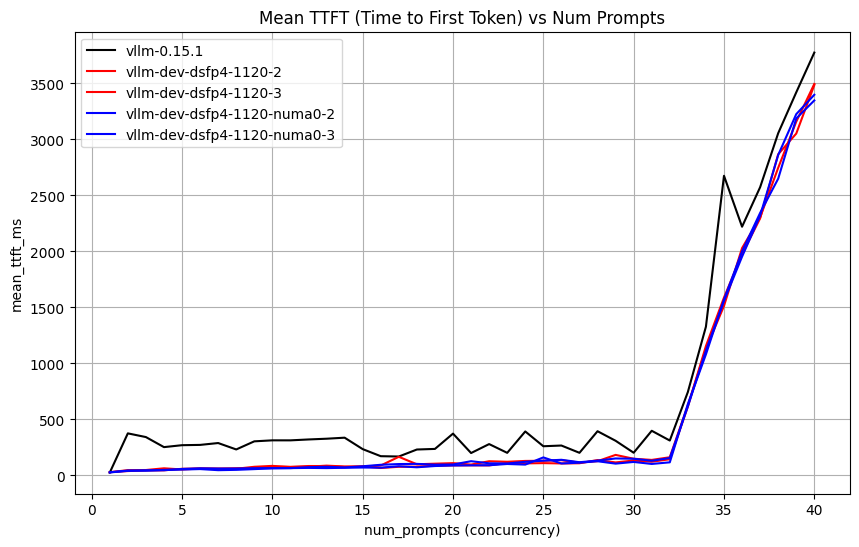

In [19]:
plt.figure(figsize=(10, 6))

for _, case in case_map.items():

    if color_map[case] == "grey":
        continue
        
    print(f"case: {case}")
    
    temp_df = df[ df['case'] == case ]

    if temp_df.empty:
        continue  # skip if no data

    plt.plot(
        temp_df["num_prompts"],
        temp_df["mean_ttft_ms"],
        #temp_df["median_ttft_ms"],
        color= color_map[case],
        label= case
    )

# Move these OUTSIDE the loop
plt.xlabel("num_prompts (concurrency)")
plt.ylabel("mean_ttft_ms")
plt.title("Mean TTFT (Time to First Token) vs Num Prompts")
plt.legend()
plt.grid(True)

plt.show()

case: vllm-0.15.1
case: vllm-dev-dsfp4-1120-2
case: vllm-dev-dsfp4-1120-3
case: vllm-dev-dsfp4-1120-numa0-2
case: vllm-dev-dsfp4-1120-numa0-3


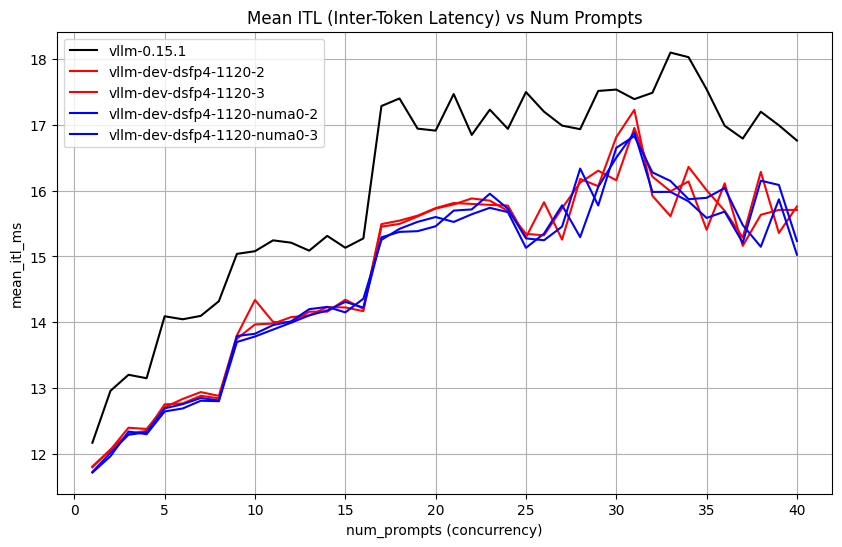

In [20]:
plt.figure(figsize=(10, 6))

for _, case in case_map.items():

    if color_map[case] == "grey":
        continue
    
    print(f"case: {case}")

    
    temp_df = df[ df['case'] == case ]

    if temp_df.empty:
        continue  # skip if no data

    plt.plot(
        temp_df["num_prompts"],
        temp_df["mean_itl_ms"],
        color= color_map[case],
        label= case
    )

# Move these OUTSIDE the loop
plt.xlabel("num_prompts (concurrency)")
plt.ylabel("mean_itl_ms")
plt.title("Mean ITL (Inter-Token Latency) vs Num Prompts")
plt.legend()
plt.grid(True)

plt.show()

case: vllm-0.15.1
case: vllm-dev-dsfp4-1120-2
case: vllm-dev-dsfp4-1120-3
case: vllm-dev-dsfp4-1120-numa0-2
case: vllm-dev-dsfp4-1120-numa0-3


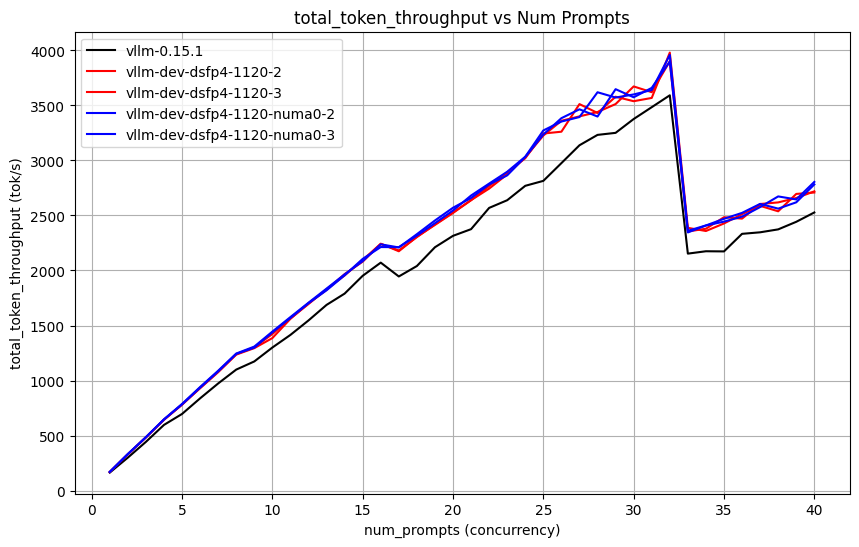

In [21]:
plt.figure(figsize=(10, 6))

for _, case in case_map.items():

    if color_map[case] == "grey":
        continue
    
    print(f"case: {case}")
    
    temp_df = df[ df['case'] == case ]

    if temp_df.empty:
        continue  # skip if no data

    plt.plot(
        temp_df["num_prompts"],
        temp_df["total_token_throughput"],
        color= color_map[case],
        label= case
    )

# Move these OUTSIDE the loop
plt.xlabel("num_prompts (concurrency)")
plt.ylabel("total_token_throughput (tok/s)")
plt.title("total_token_throughput vs Num Prompts")
plt.legend()
plt.grid(True)

plt.show()